# **Emotion Classification with RNNs, LSTMs & GRUs**
Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an** Advanced Bidirectional GRU.**

# **1. Import Libraries**

Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.



basic librarys import karaychya

dataset load from HuggingFace

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset


#basic librarys import karaychya
#library = datasets
#dataset load from HuggingFace

# **2. Load Dataset**
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [2]:
from datasets import load_dataset

ds = load_dataset("dair-ai/emotion", "split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
load_dataset('dair-ai/emotion')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']


In [5]:
label_names = emotion_dataset['train'].features['label'].names

In [6]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [7]:
train_label

Column([0, 0, 3, 2, 3])

In [8]:
for i in train_label:
  print(label_names[i])
  # instead of this we can write list comprehension [label_names[i] for i in train_label] %%

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [9]:
df_train = pd.DataFrame(
    {
       'text' :  train_text,
       'label' : [label_names[i] for i in train_label]
    }
)
df_test = pd.DataFrame(
    {
       'text' :  test_text,
       'label' : [label_names[i] for i in test_label]
    }
)
#dataframe created by combining two things i.e train & test

In [10]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [11]:
df_train.isnull().sum()

,0
text,0
label,0


# **3. Exploratory Data Analysis (EDA)**
Visualize class distribution across the 6 emotion labels.



<Axes: xlabel='label', ylabel='count'>

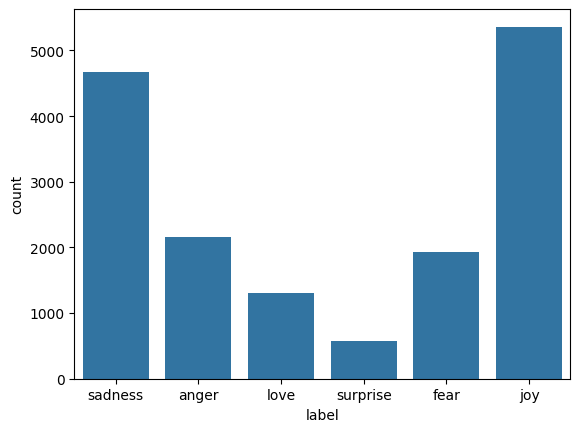

In [12]:
sns.countplot(x='label', data=df_train)

In [13]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

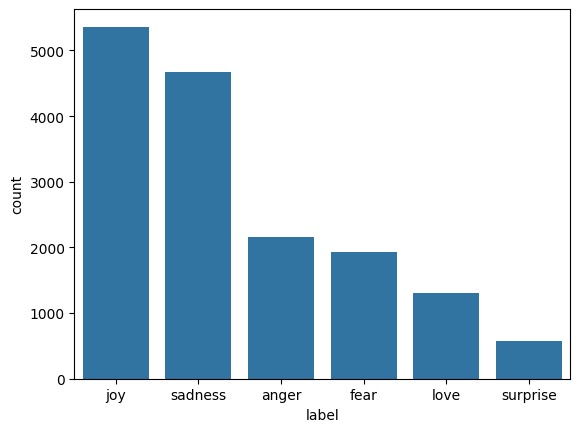

In [14]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

# **4. Data Preprocessing - Using NLP**
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")


Vocabulary Size: 15213
Max Sentence Length: 50


# **5. Shared Training Utilities**
Compute balanced class weights to handle dataset skew and setup early stopping.

In [16]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# **6. Phase 1 — Plain Foundational Models**
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

**6.1 Model 1 — Simple RNN**

Plain unrolled Recurrent Neural Network.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.1554 - loss: 2.0444 - val_accuracy: 0.1285 - val_loss: 1.8297
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1408 - loss: 1.8949 - val_accuracy: 0.1080 - val_loss: 1.8106
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.1336 - loss: 1.8292 - val_accuracy: 0.0345 - val_loss: 1.8631
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.1324 - loss: 1.8085 - val_accuracy: 0.1830 - val_loss: 1.7960
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1386 - loss: 1.8034 - val_accuracy: 0.0360 - val_loss: 1.8011
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.1501 - loss: 1.8022 - val_accuracy: 0.0820 - val_loss: 1.8226
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1351 - loss: 1.8017 - val_accuracy: 0.1165 - val_loss: 1.7606
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.1464 - loss: 1.8015 - 

**6.2 Model 2 — Standard LSTM**

Plain stacked Long Short-Term Memory network.

In [20]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 111ms/step - accuracy: 0.1512 - loss: 1.7948 - val_accuracy: 0.0795 - val_loss: 1.7862
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.1586 - loss: 1.7935 - val_accuracy: 0.3195 - val_loss: 1.7836
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 112ms/step - accuracy: 0.1666 - loss: 1.7927 - val_accuracy: 0.0820 - val_loss: 1.8044
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0795 - loss: 1.7862
LSTM Loss: 1.7861882448196411
LSTM Accuracy: 0.0794999971985817


**6.3 Model 3 — Standard GRU**

Plain stacked Gated Recurrent Unit network.

In [22]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.1447 - loss: 1.7965 - val_accuracy: 0.1375 - val_loss: 1.7949
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.1621 - loss: 1.7958 - val_accuracy: 0.1375 - val_loss: 1.7924
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.1642 - loss: 1.7942 - val_accuracy: 0.2840 - val_loss: 1.7953
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1375 - loss: 1.7949
GRU Loss: 1.7949035167694092
GRU Accuracy: 0.13750000298023224


**6.4 Phase 1 Ranking & Selection**

Rank foundational models to pick the best base cell for Phase 2.

In [23]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.794904,0.1375
0,RNN,1.760571,0.1165
1,LSTM,1.786188,0.0795


# **7. Phase 2 — Advanced Bidirectional GRU**
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

**7.1 Model 4 — Advanced Stacked Bidirectional GRU**

In [24]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train & Evaluate Advanced Bidirectional GRU**

In [25]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 226ms/step - accuracy: 0.5700 - loss: 1.0484 - val_accuracy: 0.8920 - val_loss: 0.3172
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.9202 - loss: 0.2335 - val_accuracy: 0.9100 - val_loss: 0.3072
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 107s 215ms/step - accuracy: 0.9466 - loss: 0.1448 - val_accuracy: 0.9205 - val_loss: 0.2391
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 230ms/step - accuracy: 0.9624 - loss: 0.1077 - val_accuracy: 0.9215 - val_loss: 0.2306
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.9706 - loss: 0.0837 - val_accuracy: 0.9160 - val_loss: 0.2708
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 146s 232ms/step - accuracy: 0.9746 - loss: 0.0742 - val_accuracy: 0.9225 - val_loss: 0.2496
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 109s 218ms/step - accuracy: 0.9788 - loss: 0.0624 - val_accuracy: 0.9205 - val_loss: 0.2962


In [27]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9215 - loss: 0.2306
BiGRU Loss: 0.2305706888437271
BiGRU Accuracy: 0.921500027179718


# **8. Overall Evaluation & Bias Analysis**
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

**8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)**

In [28]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step


<Axes: >

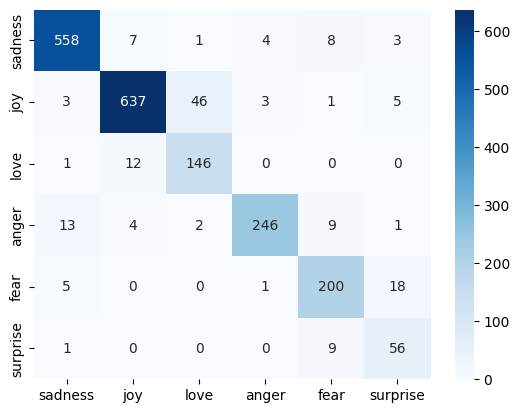

In [29]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

# **9. Final Predictions**
Test the winning model on unseen sample sentences.

In [30]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


# **10. Save Model & Tokenizer**
Export trained model and tokenizer artifacts for API deployment.

In [31]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)
